# Toy Regression with Deep Ensembles

This notebook reproduces Figure 1 of Lakshminarayanan et al. (2017),
"Simple and Scalable Predictive Uncertainty Estimation using Deep
Ensembles". The goal is to illustrate, on a simple 1D regression
problem, why two ingredients are needed to obtain meaningful
predictive uncertainty: training the network to predict its own
variance, and combining several networks into an ensemble.

We compare four setups:

1. An ensemble of 5 networks trained with MSE; uncertainty is taken as
   the empirical variance of the 5 point predictions.
2. A single network trained with the Gaussian negative log-likelihood
   (NLL), which outputs both a predicted mean and a predicted variance.
3. The same single NLL network with adversarial training (FGSM).
4. An ensemble of 5 NLL networks combined as a mixture of Gaussians.

The dataset is 20 noisy samples of `y = x^3`, with `x` restricted to
a small region. We evaluate the predictions on a wider range to
visualize how each setup behaves outside the training data.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Reproducibility
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Toy dataset

Following the paper, we generate 20 training points from
`y = x^3 + epsilon` with `epsilon ~ N(0, 9)`. The training inputs are
sampled uniformly in `[-4, 4]`. At test time we evaluate predictions
on a wider interval `[-6, 6]` to see how each model behaves in the
extrapolation regions on either side of the training data.

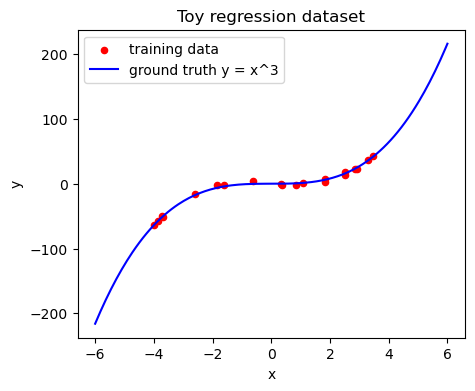

In [2]:
def make_toy_dataset(n_train=20, x_range=(-4.0, 4.0), noise_std=3.0, seed=0):
    rng = np.random.default_rng(seed)
    x_train = rng.uniform(x_range[0], x_range[1], size=n_train).astype(np.float32)
    y_train = x_train**3 + rng.normal(0.0, noise_std, size=n_train).astype(np.float32)
    return x_train, y_train


x_train, y_train = make_toy_dataset()

# Test grid covers a wider range than the training data
x_test = np.linspace(-6.0, 6.0, 200, dtype=np.float32)
y_true = x_test ** 3   # the noise-free ground truth, for plotting

# Quick visual check
plt.figure(figsize=(5, 4))
plt.scatter(x_train, y_train, c="red", s=20, label="training data")
plt.plot(x_test, y_true, "b-", lw=1.5, label="ground truth y = x^3")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Toy regression dataset")
plt.show()

## The Gaussian MLP

For NLL training, the network outputs two values: a predicted mean
`mu(x)` and a predicted variance `sigma^2(x)`. To enforce positivity
of the variance, we apply a softplus to the raw output and add a small
constant for numerical stability. The architecture is a small MLP with
one hidden layer of 100 units and ReLU activations, following the
setup of Hernandez-Lobato and Adams (2015) used by the paper.

For the MSE baseline (setup 1), we use the same architecture but
with a single output and no variance head.

In [3]:
class GaussianMLP(nn.Module):
    """MLP that outputs a predicted mean and variance"""

    def __init__(self, in_dim=1, hidden_dim=100, min_var=1e-6):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, 1)
        self.fc_var = nn.Linear(hidden_dim, 1)
        self.min_var = min_var

    def forward(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        var = F.softplus(self.fc_var(h)) + self.min_var
        return mu.squeeze(-1), var.squeeze(-1)


class MSEMLP(nn.Module):
    """Standard MLP with a single output, used as MSE baseline"""

    def __init__(self, in_dim=1, hidden_dim=100):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_out(h).squeeze(-1)

## Gaussian negative log-likelihood

The training criterion for the probabilistic networks is the Gaussian
NLL of equation (1) in the paper:

    -log p(y | x) = (1/2) log sigma^2(x) + (y - mu(x))^2 / (2 sigma^2(x)) + const.

The constant term is dropped since it does not depend on the
parameters.

In [ ]:
def gaussian_nll(mu, var, y):
    return (0.5*torch.log(var) + 0.5*(y-mu)**2/var).mean()

## Training a single network

We train each network for a fixed number of epochs with full-batch
gradient descent (the dataset is tiny). The default values follow the
paper as closely as possible: Adam optimizer, learning rate around
0.1, no weight decay. Training is fast enough that we can repeat it
many times to build the ensemble.

In [5]:
def to_tensor(x):
    """1D numpy array -> 2D tensor of shape (N, 1) on the right device"""
    return torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(-1)


def train_gaussian_net(x_train, y_train, n_epochs=2000, lr=0.1, use_adversarial=False, eps=0.08):
    """Train a single GaussianMLP with NLL, optionally with FGSM adversarial training"""
    model = GaussianMLP().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    x = to_tensor(x_train)
    y = torch.tensor(y_train, dtype=torch.float32, device=device)

    for _ in range(n_epochs):
        opt.zero_grad()

        if use_adversarial:
            # First forward to compute the gradient w.r.t. the input
            x_adv = x.clone().detach().requires_grad_(True)
            mu, var = model(x_adv)
            loss = gaussian_nll(mu, var, y)
            grad_x = torch.autograd.grad(loss, x_adv)[0]
            x_perturbed = x + eps * grad_x.sign()

            # Re-forward on both clean and adversarial inputs
            mu_c, var_c = model(x)
            mu_a, var_a = model(x_perturbed.detach())
            loss = gaussian_nll(mu_c, var_c, y) + gaussian_nll(mu_a, var_a, y)
        else:
            mu, var = model(x)
            loss = gaussian_nll(mu, var, y)

        loss.backward()
        opt.step()

    return model


def train_mse_net(x_train, y_train, n_epochs=2000, lr=0.1):
    """Train a single MSEMLP with squared error loss"""
    model = MSEMLP().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    x = to_tensor(x_train)
    y = torch.tensor(y_train, dtype=torch.float32, device=device)

    for _ in range(n_epochs):
        opt.zero_grad()
        pred = model(x)
        loss = F.mse_loss(pred, y)
        loss.backward()
        opt.step()

    return model

## Training the ensemble

The ensemble is built simply by training `M` networks independently
from different random initializations. 
With M = 5 networks and our small dataset, the whole ensemble trains in a few seconds on CPU.

In [ ]:
def train_ensemble(x_train, y_train, M=5, **kwargs):
    """Train M independent GaussianMLPs"""
    models = []
    for m in range(M):
        torch.manual_seed(SEED + m)   # different init for each member
        model = train_gaussian_net(x_train, y_train, **kwargs)
        models.append(model)
    return models


@torch.no_grad()
def predict_ensemble(models, x):
    """Combines ensemble predictions into a Gaussian Mixture Model"""
    x_t = to_tensor(x)
    mus, varz = [], []
    for model in models:
        model.eval()
        mu, var = model(x_t)
        mus.append(mu.cpu().numpy())
        varz.append(var.cpu().numpy())

    mus = np.stack(mus)     # (M, N)
    varz = np.stack(varz)   # (M, N)

    mu_star = mus.mean(axis=0)
    var_star = (varz + mus ** 2).mean(axis=0) - mu_star ** 2
    return mu_star, var_star


@torch.no_grad()
def predict_mse_ensemble(models, x):
    """Empirical variance of point predictions, used for the MSE baseline"""
    x_t = to_tensor(x)
    preds = []
    for model in models:
        model.eval()
        preds.append(model(x_t).cpu().numpy())
    preds = np.stack(preds)
    return preds.mean(axis=0), preds.var(axis=0)

## Running the four setups



In [7]:
# Setup 1: ensemble of 5 MSE networks
mse_ensemble = []
for m in range(5):
    torch.manual_seed(SEED + m)
    mse_ensemble.append(train_mse_net(x_train, y_train))

# Setup 2: single Gaussian NLL network
torch.manual_seed(SEED)
single_nll = train_gaussian_net(x_train, y_train)

# Setup 3: single Gaussian NLL network with adversarial training
torch.manual_seed(SEED)
single_nll_adv = train_gaussian_net(x_train, y_train, use_adversarial=True)

# Setup 4: ensemble of 5 Gaussian NLL networks
nll_ensemble = train_ensemble(x_train, y_train, M=5)

print("All four setups trained.")

All four setups trained.


## Reproducing Figure 1

We plot, for each of the four setups, the predicted mean as a solid
line and a 3-sigma confidence band as a shaded region. The blue curve
is the noise-free ground truth `y = x^3`, and the red dots are the
training points. The expected qualitative behaviour, following the
paper, is:

**Setup 1 (MSE ensemble):** the variance stays small even far from the training data because all five networks extrapolate similarly.

**Setup 2 (single NLL):** the variance is roughly constant and matches the data noise near the training points, but does not grow in the extrapolation regions.

**Setup 3 (single NLL + adversarial):** a small improvement, mostly near the training points.

**Setup 4 (NLL ensemble):** the confidence band widens sharply outside the training range, which is the desired behaviour.

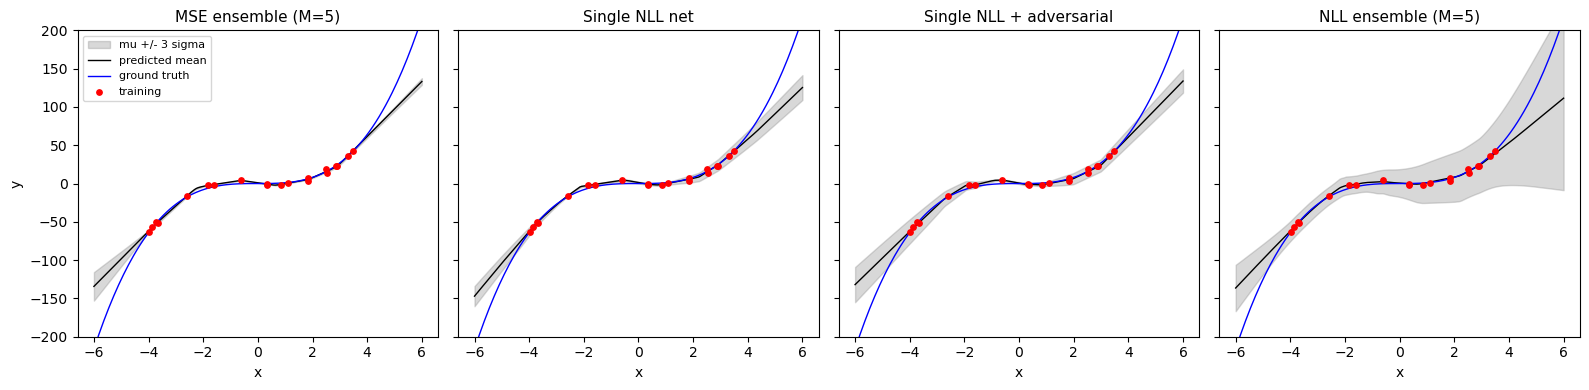

In [8]:
mu1, var1 = predict_mse_ensemble(mse_ensemble, x_test)

with torch.no_grad():
    single_nll.eval()
    mu2_t, var2_t = single_nll(to_tensor(x_test))
    mu2, var2 = mu2_t.cpu().numpy(), var2_t.cpu().numpy()

    single_nll_adv.eval()
    mu3_t, var3_t = single_nll_adv(to_tensor(x_test))
    mu3, var3 = mu3_t.cpu().numpy(), var3_t.cpu().numpy()

mu4, var4 = predict_ensemble(nll_ensemble, x_test)

results = [
    ("MSE ensemble (M=5)", mu1, var1),
    ("Single NLL net", mu2, var2),
    ("Single NLL + adversarial", mu3, var3),
    ("NLL ensemble (M=5)", mu4, var4),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (title, mu, var) in zip(axes, results):
    std = np.sqrt(var)
    ax.fill_between(x_test, mu - 3 * std, mu + 3 * std,
                    color="gray", alpha=0.3, label="mu +/- 3 sigma")
    ax.plot(x_test, mu, color="black", lw=1.0, label="predicted mean")
    ax.plot(x_test, y_true, color="blue", lw=1.0, label="ground truth")
    ax.scatter(x_train, y_train, color="red", s=15, zorder=3, label="training")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylim(-200, 200)
axes[0].set_ylabel("y")
axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("figures/toy_regression.png", bbox_inches="tight")
plt.show()